Installing required libraries...

Importing libraries...

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1680)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1680, 100) │  2,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1678, 256) │     77,056 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1677, 256) │    102,656 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1676, 256) │    128,256 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1675, 256) │    153,856 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    262,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,724,995 (10.40 MB)

 Trainable params: 724,995 (2.77 MB)

 Non-trainable params: 2,000,000 (7.63 MB)


Compiling model...

Starting model training...
Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.3432 - loss: 1.6619 - val_accuracy: 0.2597 - val_loss: 0.9896
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4129 - loss: 1.0328 - val_accuracy: 0.6071 - val_loss: 1.0276
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4701 - loss: 0.9549 - val_accuracy: 0.2500 - val_loss: 0.9654
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4549 - loss: 0.8600 - val_accuracy: 0.3312 - val_loss: 1.1901
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5438 - loss: 0.8017 - val_accuracy: 0.5195 - val_loss: 0.9040
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5535 - loss: 0.6739 - val_accuracy: 0.6364 - val_loss: 0.8387
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6220 - loss: 0.5886 - val_accuracy: 0.5844 - val_loss: 0.9523
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms

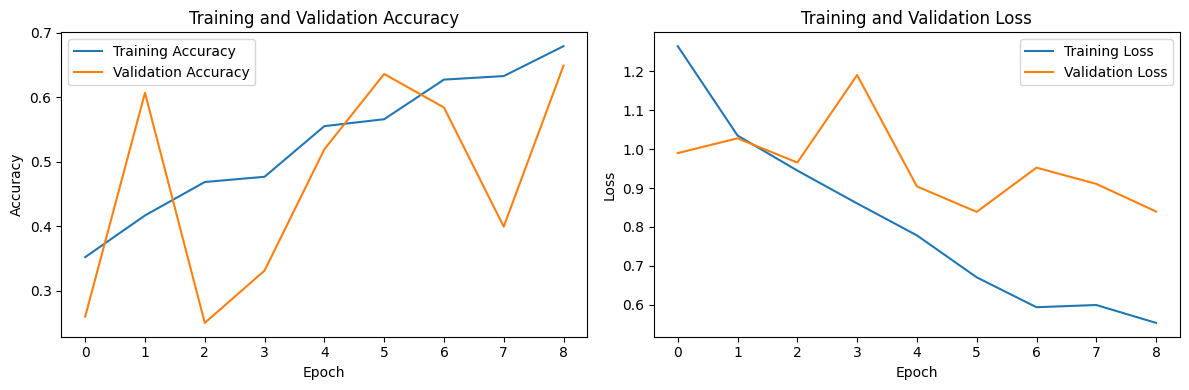


Making a prediction on new, unseen data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step

Prediction Probabilities: [[0.3056921 0.4052843 0.2890236]]
Input Question: Did you or did you not approve the new tax policy?
Input Answer: What I can tell you is that our team is working very hard to address the economic challenges this country is facing, and we have made great progress.
Predicted Label: Clear Non-Reply


In [1]:
## --------------------------------------------------
## 1. Install Libraries
## --------------------------------------------------
# We need 'datasets' to load the data from Hugging Face
# and 'tensorflow' to build and train the CNN.
print("Installing required libraries...")
!pip install datasets tensorflow scikit-learn -q


## --------------------------------------------------
## 2. Import Libraries
## --------------------------------------------------
print("\nImporting libraries...")
import numpy as np
import tensorflow as tf
import os # --- ADDED: For file/path operations ---
# --- MODIFIED: Need more layers for the functional API ---
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input, concatenate
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping  # --- ADDED: For smarter training
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
# --- ADDED for detailed F1/macro analysis ---
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report
)


## --------------------------------------------------
## 3. Load and Prepare the Dataset
## --------------------------------------------------
# (This cell is identical to your code)
print("\nLoading dataset...")
dataset = load_dataset("ailsntua/QEvasion")
train_data = dataset['train']
test_data = dataset['test']

print("Preparing text data...")
def combine_text(example):
    return example['question'] + " [SEP] " + example['interview_answer']
train_texts = [combine_text(ex) for ex in train_data]
test_texts = [combine_text(ex) for ex in test_data]

print("Preparing labels...")
train_labels_raw = [ex['clarity_label'] for ex in train_data]
test_labels_raw = [ex['clarity_label'] for ex in test_data]

label_encoder = LabelEncoder()
label_encoder.fit(train_labels_raw)
train_labels = label_encoder.transform(train_labels_raw)
test_labels = label_encoder.transform(test_labels_raw)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(f"\nTraining samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(zip(np.unique(train_labels), weights))
print(f"\nCalculated Class Weights: {class_weight_dict}")


## --------------------------------------------------
## 4. Tokenize and Pad Text
## --------------------------------------------------
# (This cell is identical to your code)
print("\nTokenizing text...")
vocab_size = 20000
max_length = 1680
embedding_dim = 100 # --- NOTE: This MUST match the GloVe file (glove.6B.100d.txt) ---

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

print(f"Padding sequences to length {max_length}...")
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print(f"Shape of padded training data: {train_padded.shape}")
print(f"Shape of padded test data: {test_padded.shape}")


## --------------------------------------------------
## 4.5: Download and Prepare GloVe Embeddings
## --------------------------------------------------
# --- THIS IS THE CORE OF STRATEGY 1 ---
print("\nDownloading GloVe embeddings (this may take a few minutes)...")
# Download the 100-dimension GloVe embeddings (862MB)
!wget http://nlp.stanford.edu/data/glove.6B.zip -q
!unzip -q glove.6B.zip

print("Parsing GloVe file...")
# Load the 100d embeddings into a dictionary
glove_file_path = 'glove.6B.100d.txt'
embeddings_index = {}
with open(glove_file_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")

# --- Create an Embedding Matrix for our vocabulary ---
# This matrix will have shape (vocab_size, embedding_dim)
# We initialize it with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Get the word-to-integer mapping from our tokenizer
word_index = tokenizer.word_index

# Loop through our vocabulary and fill the matrix
# with the pre-trained GloVe vectors
num_words_found = 0
for word, i in word_index.items():
    if i < vocab_size: # We only care about words in our vocab
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Word was found in GloVe, add it to our matrix
            embedding_matrix[i] = embedding_vector
            num_words_found += 1

print(f"Filled {num_words_found} / {vocab_size} words from our vocab into the embedding matrix.")


## --------------------------------------------------
## 5. Build the Model (Using GloVe)
## --------------------------------------------------
# --- THIS CELL IS MODIFIED TO USE THE GLOVE MATRIX ---

print("\nBuilding the CNN model with GloVe Embeddings...")

# 1. Define the input layer
main_input = Input(shape=(max_length,), dtype='int32')

# 2. Embedding Layer
# --- THIS IS THE KEY CHANGE ---
embed_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length,
    weights=[embedding_matrix], # 1. Load the pre-trained GloVe weights
    trainable=False             # 2. Freeze the layer (CRITICAL for anti-overfitting)
)(main_input)
# -----------------------------

# 3. Parallel Convolutional Layers (A "sane" multi-filter model)
pool_layers = []

# We use a robust, smaller set of kernel sizes
for kernel_size in [3, 4, 5, 6]:
    conv = Conv1D(filters=256, # Using 256 filters
                  kernel_size=kernel_size,
                  activation='relu')(embed_layer)
    pool = GlobalMaxPooling1D()(conv)
    pool_layers.append(pool)

# 4. Concatenate
# We merge the results of all 4 branches
merged = concatenate(pool_layers)

# 5. Fully Connected (Dense) Layers
dense1 = Dense(256, activation='relu')(merged) # A dense layer to learn from the merged features
dropout1 = Dropout(0.5)(dense1)

# 6. Output Layer
output = Dense(num_classes, activation='softmax')(dropout1)

# 7. Create the final model
model = Model(inputs=main_input, outputs=output)

# Show a summary of the new, more complex model
model.summary()


## --------------------------------------------------
## 6. Compile the Model
## --------------------------------------------------
# (This cell is identical to your code)
print("\nCompiling model...")
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## --------------------------------------------------
## 7. Train the Model
## --------------------------------------------------
# (This cell is identical to your code)
print("\nStarting model training...")

num_epochs = 20

early_stopping_callback = EarlyStopping(monitor='val_loss',
                                        patience=3,
                                        restore_best_weights=True)

history = model.fit(
    train_padded,
    train_labels,
    epochs=num_epochs,
    validation_data=(test_padded, test_labels),
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_callback]
)

print("Training complete.")


## --------------------------------------------------
## 8. Evaluate the Model (with Macro F1-Score)
## --------------------------------------------------
# (This cell is identical to your code)
print("\nEvaluating model performance on test set...")

loss, accuracy_keras = model.evaluate(test_padded, test_labels, verbose=0)
print(f"Keras Basic Evaluation:")
print(f"  Test Set Accuracy: {accuracy_keras * 100:.2f}%")
print(f"  Test Set Loss: {loss:.4f}")

print("\nCalculating detailed metrics (Macro F1, Precision, Recall)...")
predictions_prob = model.predict(test_padded)
predictions_class = np.argmax(predictions_prob, axis=1)

acc_sklearn = accuracy_score(test_labels, predictions_class)
f1_macro = f1_score(test_labels, predictions_class, average='macro', zero_division=0)
precision_macro = precision_score(test_labels, predictions_class, average='macro', zero_division=0)
recall_macro = recall_score(test_labels, predictions_class, average='macro', zero_division=0)

print(f"\nScikit-learn Macro-Averaged Metrics:")
print(f"  Accuracy (Sklearn): {acc_sklearn * 100:.2f}%")
print(f"  F1 Score (Macro):   {f1_macro:.4f}")
print(f"  Precision (Macro):  {precision_macro:.4f}")
print(f"  Recall (Macro):     {recall_macro:.4f}")

print("\n" + "="*50)
print("           Full Classification Report")
print("="*50)
report = classification_report(test_labels, predictions_class, target_names=class_names, zero_division=0)
print(report)
print("="*50)

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


## --------------------------------------------------
## 9. Make a Prediction on New Data
## --------------------------------------------------
# (This cell is identical to your code)
print("\nMaking a prediction on new, unseen data...")

new_question = "Did you or did you not approve the new tax policy?"
new_answer = "What I can tell you is that our team is working very hard to address the economic challenges this country is facing, and we have made great progress."

new_text = [new_question + " [SEP] " + new_answer]
new_sequences = tokenizer.texts_to_sequences(new_text)
new_padded = pad_sequences(new_sequences, maxlen=max_length, padding='post', truncating='post')

prediction = model.predict(new_padded)

print(f"\nPrediction Probabilities: {prediction}")
predicted_class_index = np.argmax(prediction[0])
predicted_class_name = label_encoder.inverse_transform([predicted_class_index])

print(f"Input Question: {new_question}")
print(f"Input Answer: {new_answer}")
print(f"Predicted Label: {predicted_class_name[0]}")